# Mapping Geographic Accessibility

## Contents of This Notebook

## Section A: Accessibility Analysis

**Question** : Where are stroke care resources located and who has access?

### Part 1: Mapping Stroke Centers

In this section, we will input:
* County shapefile
* Basic stroke center data
* Advanced stroke center data

And produce: 
* NY-NJ-CT county map of basic stroke centers
* NY-NJ-CT county map of advanced stroke centers

To get the county boundaries, we use the official Census TIGER/Line counties shapefile from 2020. We use data from 2020 rather than 2023 so that the counties match that of our other datasets, which use the old CT counties, rather than the new planning regions. First, we read the shapefile:

In [8]:
cd C:/Users/janec/Documents/Github/stroke-burden-index/data/geographic_accessibility_data

C:\Users\janec\Documents\Github\stroke-burden-index\data\geographic_accessibility_data


In [9]:
# Importing necessary packages
import geopandas as gpd
import pandas as pd

In [10]:
# Reading shapefile from zip file
counties = gpd.read_file(
    "tl_2020_us_county.zip"
)

From this file, we take only the county boundaries for NY, NJ, and CT.
* CT = 09
* NJ = 34
* NY = 36

In [12]:
counties = counties[
    counties["STATEFP"].isin(
        ["09", "34", "36"]
    )
]

We also create state boundaries, which will give thicker outlines around the state in our maps. 

In [14]:
states = counties.dissolve(
    by="STATEFP"
)

Next, we load the geocoded stroke center data.

#### Basic Stroke Centers

First, we load the data for basic stroke centers. Basic stroke centers encompass the following designations:
* Primary Stroke Center
* Acute Care Stroke Center

This serves as an indicator for the **bare minimum** access to stroke care. These facilities are certified to rapidly diagnose and treat acute strokes by administering critical clot-busting medications such as tPA to quickly restore blood flow to the brain. In more complex cases where a patient may require surgery, these facilities are generally not sufficient and the patient must be transferred.

In [18]:
# Loading stroke center files 
ct_basic = pd.read_csv(
    "ct_basic_geocoded.csv"
)

ny_basic = pd.read_csv(
    "ny_primary_stroke_centers_geocoded.csv"
)

nj_basic = pd.read_csv(
    "nj_primary_stroke_centers_geocoded.csv"
)

# Combining all 3 states

stroke_basic = pd.concat(
    [ct_basic, ny_basic, nj_basic],
    ignore_index=True
)

Next, we convert the stroke centers into GeoDataFrames.

In [20]:
basic_gdf = gpd.GeoDataFrame(
    stroke_basic,
    geometry=gpd.points_from_xy(
        stroke_basic["longitude"],
        stroke_basic["latitude"]
    ),
    crs="EPSG:4326"
)

We use matplotlib to plot county boundaries + stroke centers:

In [22]:
import matplotlib.pyplot as plt

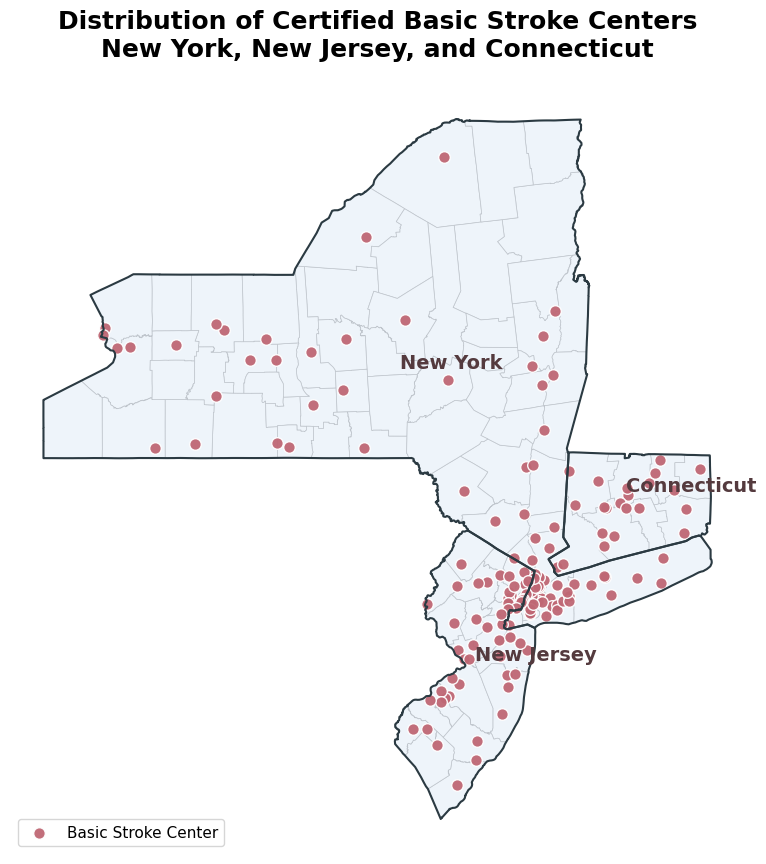

In [23]:
fig, ax = plt.subplots(
    figsize=(14, 10)
)

# County polygons

counties.plot(
    ax=ax,
    color="#EEF4FA",
    edgecolor="#BFC5CC",
    linewidth=0.5
)

# State boundaries

states.boundary.plot(
    ax=ax,
    color="#2B3A42",
    linewidth=1.5
)

# Basic stroke centers

basic_gdf.plot(
    ax=ax,
    marker="o",
    color="#bf6774",
    markersize=70,
    edgecolor="white",
    linewidth=1,
    alpha=0.95,
    label="Basic Stroke Center"
)

# Title

plt.title(
    "Distribution of Certified Basic Stroke Centers\nNew York, New Jersey, and Connecticut",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Legend

plt.legend(
    loc="lower left",
    fontsize=11
)


# State labels


ax.text(-75.5, 42.8, "New York",
        fontsize=14,
        weight="bold",
        color="#543a3e")

ax.text(-74.6, 40.2, "New Jersey",
        fontsize=14,
        weight="bold",
        color="#543a3e")

ax.text(-72.8, 41.7, "Connecticut",
        fontsize=14,
        weight="bold",
        color="#543a3e")


# Remove axes

plt.axis("off")

plt.show()

**Figure 1. Distribution of Certified Basic Stroke Centers in the New York–New Jersey–Connecticut Region.** shows the distribution of certified basic stroke centers across the New York–New Jersey–Connecticut region. Stroke centers are concentrated in major metropolitan areas, including New York City, Long Island, northern New Jersey, Hartford, and New Haven. In contrast, rural areas of upstate New York and northwestern Connecticut contain relatively few facilities, suggesting potential geographic disparities in access to acute stroke care. These patterns motivate further analysis of county-level travel times and accessibility measures.

#### Advanced Stroke Centers

Next, we load the data for advanced stroke centers. Advanced stroke centers encompass the following designations:
* Thrombectomy-Capable Stroke Centers (TSC)
* Comprehensive Stroke Centers (CSC)

This serves as an indicator for **strong** access to stroke care. These facilities are highly specialized and are equipped to treat patients suffering from severe strokes. TSCs focus on removing large blood clots via minimally invasive surgery. They are essentially a step up from a primary stroke center, and are very useful in rural areas when a patient requires surgery and the distance to the nearest comprehensive stroke center is very far. CSCs serve as the highest level of care, offering around-the-clock specialists and advanced treatments for all types of complex strokes. 

In [28]:
# Reading advanced stroke center data
ct_advanced = pd.read_csv(
    "ct_advanced_geocoded.csv"
)

ny_all = pd.read_csv(
    "ny_all_stroke_centers_geocoded.csv"
)

nj_all = pd.read_csv(
    "nj_all_stroke_centers_geocoded.csv"
)

In [29]:
# Filtering for advanced facilities only for NY and NJ
ny_advanced = ny_all[
    ny_all["designation"].isin([
        "Comprehensive Stroke Center",
        "Thrombectomy Capable Stroke Center"
    ])
]

nj_advanced = nj_all[
    nj_all["designation"] == "Comprehensive"
]

In [30]:
# Combining all three states
stroke_advanced = pd.concat(
    [
        ct_advanced,
        ny_advanced,
        nj_advanced
    ],
    ignore_index=True
)

After reading the data, we convert it to a GeoDataFrame. 

In [32]:
# Converting to a geodataframe
advanced_gdf = gpd.GeoDataFrame(
    stroke_advanced,
    geometry=gpd.points_from_xy(
        stroke_advanced["longitude"],
        stroke_advanced["latitude"]
    ),
    crs="EPSG:4326"
)

We use matplotlib to create a map of advanced stroke centers.

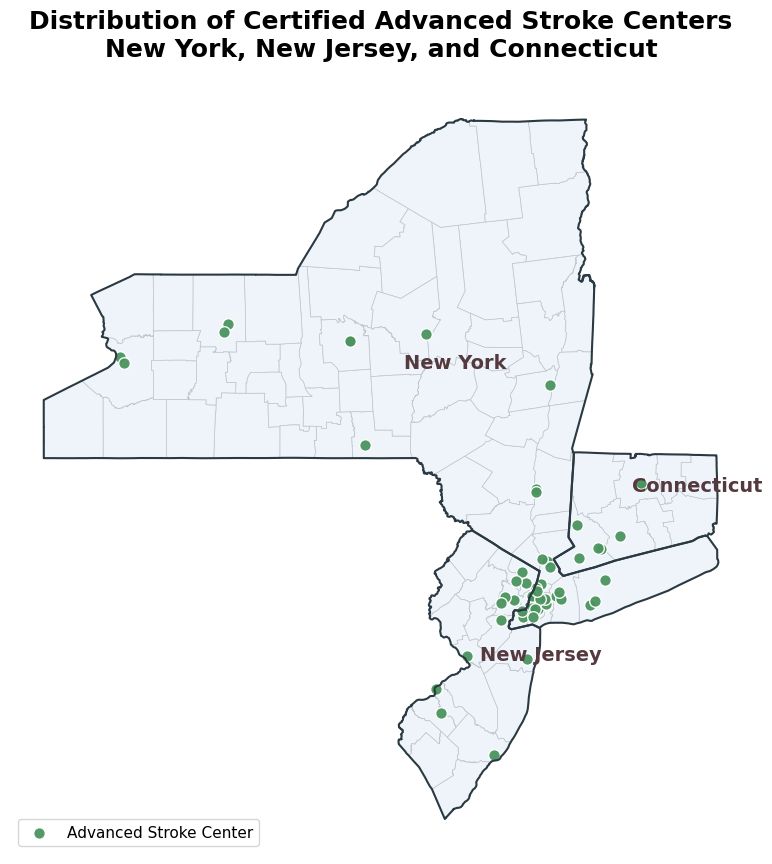

In [34]:
fig, ax = plt.subplots(
    figsize=(14, 10)
)

# County polygons

counties.plot(
    ax=ax,
    color="#EEF4FA",
    edgecolor="#BFC5CC",
    linewidth=0.5
)

# State boundaries

states.boundary.plot(
    ax=ax,
    color="#2B3A42",
    linewidth=1.5
)

# Basic stroke centers

advanced_gdf.plot(
    ax=ax,
    marker="o",
    color="#4b945f",
    markersize=70,
    edgecolor="white",
    linewidth=1,
    alpha=0.95,
    label="Advanced Stroke Center"
)

# Title

plt.title(
    "Distribution of Certified Advanced Stroke Centers\nNew York, New Jersey, and Connecticut",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Legend

plt.legend(
    loc="lower left",
    fontsize=11
)


# State labels


ax.text(-75.5, 42.8, "New York",
        fontsize=14,
        weight="bold",
        color="#543a3e")

ax.text(-74.6, 40.2, "New Jersey",
        fontsize=14,
        weight="bold",
        color="#543a3e")

ax.text(-72.8, 41.7, "Connecticut",
        fontsize=14,
        weight="bold",
        color="#543a3e")


# Remove axes

plt.axis("off")

plt.show()

**Figure 2. Distribution of Certified Advanced Stroke Centers in the New York–New Jersey–Connecticut Region.** Advanced stroke centers, including Comprehensive Stroke Centers and Thrombectomy-Capable Stroke Centers, are concentrated within major metropolitan areas such as New York City, northern New Jersey, Hartford, and New Haven. Compared with basic stroke centers, advanced facilities are fewer in number and more geographically clustered, leaving many rural counties in upstate New York and northwestern Connecticut farther from specialized stroke care. This distribution highlights potential disparities in access to advanced stroke treatment and provides the basis for subsequent analyses of travel distance, travel time, and county-level accessibility.


#### All Stroke Centers

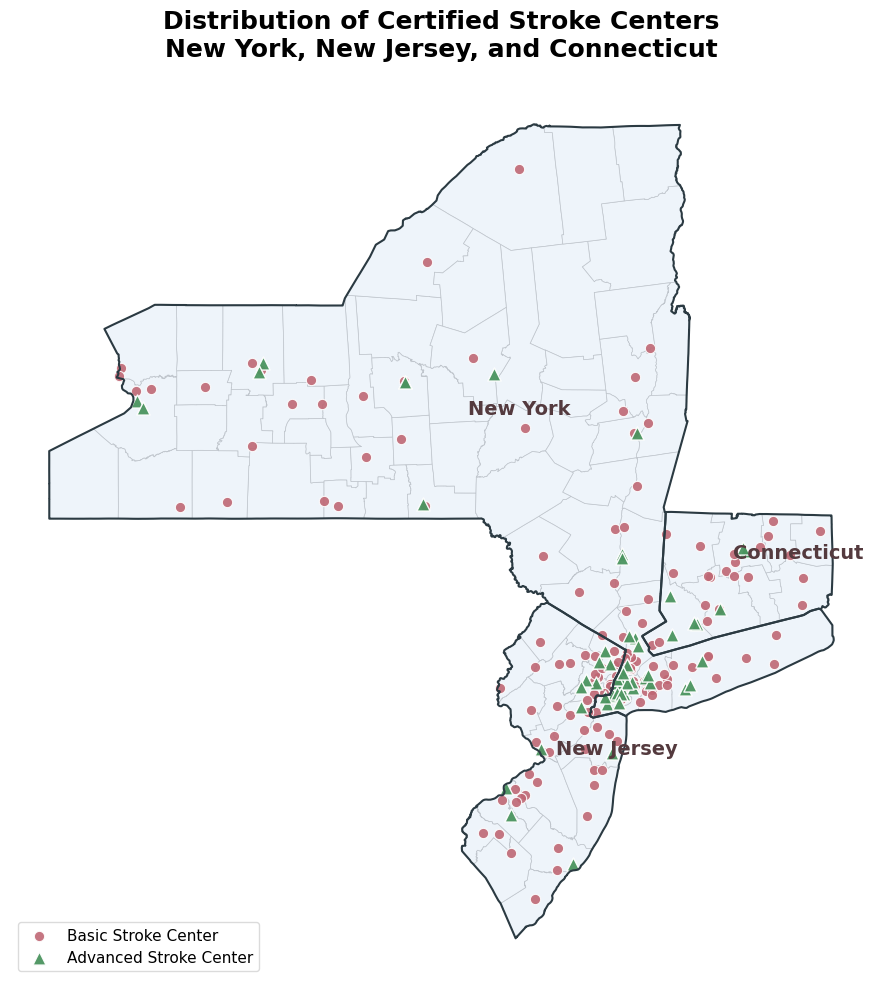

In [37]:
# Creating figure

fig, ax = plt.subplots(
    figsize=(14, 10)
)

# County polygons

counties.plot(
    ax=ax,
    color="#EEF4FA",
    edgecolor="#BFC5CC",
    linewidth=0.5
)

# State boundaries

states.boundary.plot(
    ax=ax,
    color="#2B3A42",
    linewidth=1.5
)

# Basic stroke centers

basic_gdf.plot(
    ax=ax,
    marker="o",
    color="#bf6774",
    markersize=55,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
    label="Basic Stroke Center"
)

# Advanced stroke centers

advanced_gdf.plot(
    ax=ax,
    marker="^",
    color="#4b945f",
    markersize=90,
    edgecolor="white",
    linewidth=1,
    alpha=0.95,
    label="Advanced Stroke Center"
)

# Title

plt.title(
    "Distribution of Certified Stroke Centers\nNew York, New Jersey, and Connecticut",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Legend

plt.legend(
    loc="lower left",
    fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray"
)

# State labels

ax.text(
    -75.5, 42.8,
    "New York",
    fontsize=14,
    weight="bold",
    color="#543A3E"
)

ax.text(
    -74.6, 40.2,
    "New Jersey",
    fontsize=14,
    weight="bold",
    color="#543A3E"
)

ax.text(
    -72.8, 41.7,
    "Connecticut",
    fontsize=14,
    weight="bold",
    color="#543A3E"
)

# Remove axes

plt.axis("off")

# Improve spacing

plt.tight_layout()

plt.show()

**Figure 3. Distribution of Certified Stroke Centers in the New York–New Jersey–Connecticut Region.** Blue circles represent certified Basic Stroke Centers, while orange triangles represent Advanced Stroke Centers (Comprehensive Stroke Centers and Thrombectomy-Capable Stroke Centers). Basic stroke centers are distributed throughout the region, whereas advanced stroke centers are fewer in number and are concentrated primarily within major metropolitan areas. This geographic pattern suggests that access to specialized stroke care may be more limited for residents of rural counties and provides the foundation for subsequent analyses of travel distance, travel time, and spatial accessibility.

### Part 2: Mapping Estimated Travel Time

In this section, we will create a map of estimated travel time by county. Since access to stroke care is extremely time-sensitive, we choose the categories as such:
* 0-15 min
* 15-30 min
* 30-60 min
* 60+ min

In general, stroke patients who receive the appropriate medical care within an hour are more likely to make a full recovery.

First, we load the accessibility data:

In [42]:
geo_accessibility = pd.read_csv(
    "geographic_stroke_accessibility.csv"
)

Next, we merge this data with the official Census TIGER/Line shapefile from 2020:

In [44]:
counties["fips"] = (
    counties["STATEFP"] +
    counties["COUNTYFP"]
)

In [45]:
# Converting FIPS code to strings so that we can merge

counties["fips"] = counties["fips"].astype(str).str.zfill(5)

geo_accessibility["fips"] = geo_accessibility["fips"].astype(str).str.zfill(5)

In [46]:
# Merging geographic accessibility data with shapefile

counties = counties.merge(
    geo_accessibility,
    on="fips",
    how="left"
)

Next, we have to create accessibility categories by classifying values into bins. 

In [48]:
bins = [0, 15, 30, 60, float("inf")]

labels = [
    "0–15 min",
    "15–30 min",
    "30–60 min",
    "60+ min"
]

#### Basic Stroke Care Centers

In [50]:
# Reading data

counties["basic_access"] = pd.cut(
    counties["drive_time_min"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

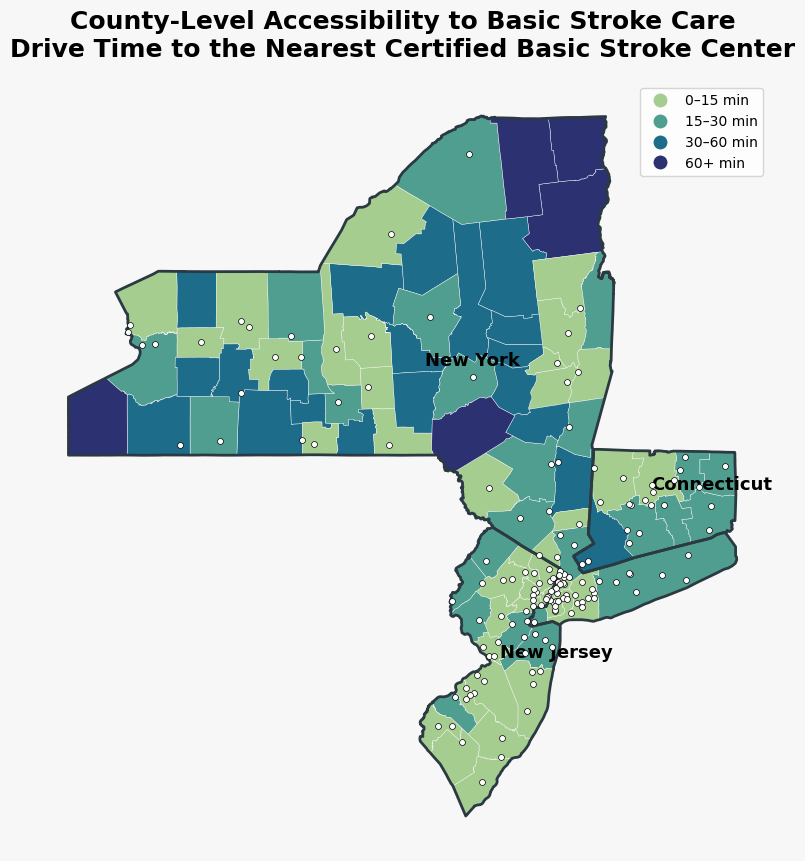

In [112]:
import seaborn

fig, ax = plt.subplots(
    figsize=(14,10),
    facecolor="#F7F7F7"
)

counties.plot(
    column="basic_access",
    cmap="crest",
    edgecolor="#F5F5F5",
    linewidth=0.3,
    legend=True,
    ax=ax,
    categorical=True
)

states.boundary.plot(
    ax=ax,
    color="#2B3A42",
    linewidth=2
)


basic_gdf.plot(
    ax=ax,
    marker="o",
    color="white",
    edgecolor="black",
    markersize=18,
    linewidth=0.5,
    zorder=5
)


legend=True,
legend_kwds={
    "title": "Drive Time",
    "loc": "lower left",
    "frameon": True
}


ax.text(
    -75.5, 42.8,
    "New York",
    fontsize=13,
    weight="bold",
    color="black"
)

ax.text(
    -74.6, 40.2,
    "New Jersey",
    fontsize=13,
    weight="bold",
    color="black"
)

ax.text(
    -72.8, 41.7,
    "Connecticut",
    fontsize=13,
    weight="bold",
    color="black"
)


plt.title(
    "County-Level Accessibility to Basic Stroke Care\nDrive Time to the Nearest Certified Basic Stroke Center",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.axis("off")

plt.show()

**Figure 4** County-level accessibility to Basic Stroke Centers across New York, New Jersey, and Connecticut. Counties are classified by estimated drive time to the nearest certified Basic Stroke Center. White circles indicate the locations of certified Basic Stroke Centers.

In [53]:
plt.savefig(
    "basic_accessibility.png",
    dpi=400,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

#### Advanced Stroke Care Centers

In [55]:
# Reading data

counties["advanced_access"] = pd.cut(
    counties["drive_time_advanced"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

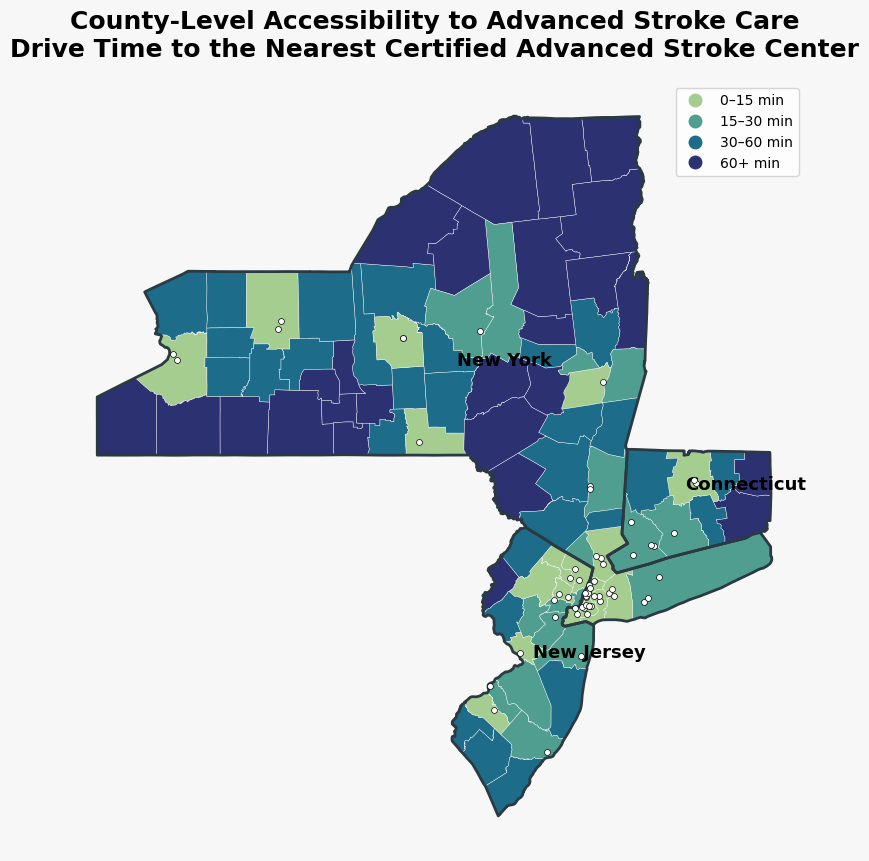

In [110]:
fig, ax = plt.subplots(
    figsize=(14,10),
    facecolor="#F7F7F7"
)

counties.plot(
    column="advanced_access",
    cmap="crest",
    edgecolor="#F5F5F5",
    linewidth=0.3,
    legend=True,
    ax=ax,
    categorical=True
)

states.boundary.plot(
    ax=ax,
    color="#2B3A42",
    linewidth=2
)


advanced_gdf.plot(
    ax=ax,
    marker="o",
    color="white",
    edgecolor="black",
    markersize=18,
    linewidth=0.5,
    zorder=5
)


legend=True,
legend_kwds={
    "title": "Drive Time",
    "loc": "lower left",
    "frameon": True
}


ax.text(
    -75.5, 42.8,
    "New York",
    fontsize=13,
    weight="bold",
    color="black"
)

ax.text(
    -74.6, 40.2,
    "New Jersey",
    fontsize=13,
    weight="bold",
    color="black"
)

ax.text(
    -72.8, 41.7,
    "Connecticut",
    fontsize=13,
    weight="bold",
    color="black"
)


plt.title(
    "County-Level Accessibility to Advanced Stroke Care\nDrive Time to the Nearest Certified Advanced Stroke Center",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.axis("off")

plt.show()

**Figure 5.** County-level accessibility to Advanced Stroke Centers across New York, New Jersey, and Connecticut. Counties are classified by estimated drive time to the nearest certified Advanced Stroke Center. White circles indicate the locations of certified Advanced Stroke Centers.

In [58]:
plt.savefig(
    "advanced_accessibility.png",
    dpi=400,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

#### All Stroke Centers

To get the estimated travel time to the nearest stroke center, we take the minimum of the estimated travel time to the nearest basic stroke center and the estimated travel time to the nearest advanced stroke center.

In [61]:
geo_accessibility["drive_time_all"] = geo_accessibility[
    ["drive_time_min", "drive_time_advanced"]
].min(axis=1)

geo_accessibility["nearest_stroke_distance_all"] = geo_accessibility[
    ["nearest_stroke_distance", "nearest_stroke_distance_advanced"]
].min(axis=1)

Next, we merge this into the full dataframe:

In [63]:
counties = counties.merge(
    geo_accessibility,
    on="fips",
    how="left"
)

We create the accessibility categories by putting the value into bins:

In [65]:
bins = [0, 15, 30, 60, float("inf")]

labels = [
    "0–15 min",
    "15–30 min",
    "30–60 min",
    "60+ min"
]

counties["access_all"] = pd.cut(
    counties["drive_time_all"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

Finally, we can plot a choropleth map displaying the estimated travel time to the nearest stroke center:

In [67]:
# Creating colorblind friendly color palette

colors = [
    "#4CC9F0",  
    "#C77DFF",  
    "#F72585",  
    "#7209B7",  
    "#3A0CA3"   
]

In [68]:
from matplotlib.colors import ListedColormap

In [69]:
custom_cmap = ListedColormap([
    "#4CC9F0",   
    "#C77DFF",   
    "#F72585",   
    "#7209B7",   
    "#3A0CA3"    
])

In [70]:
from matplotlib.lines import Line2D

In [71]:
#

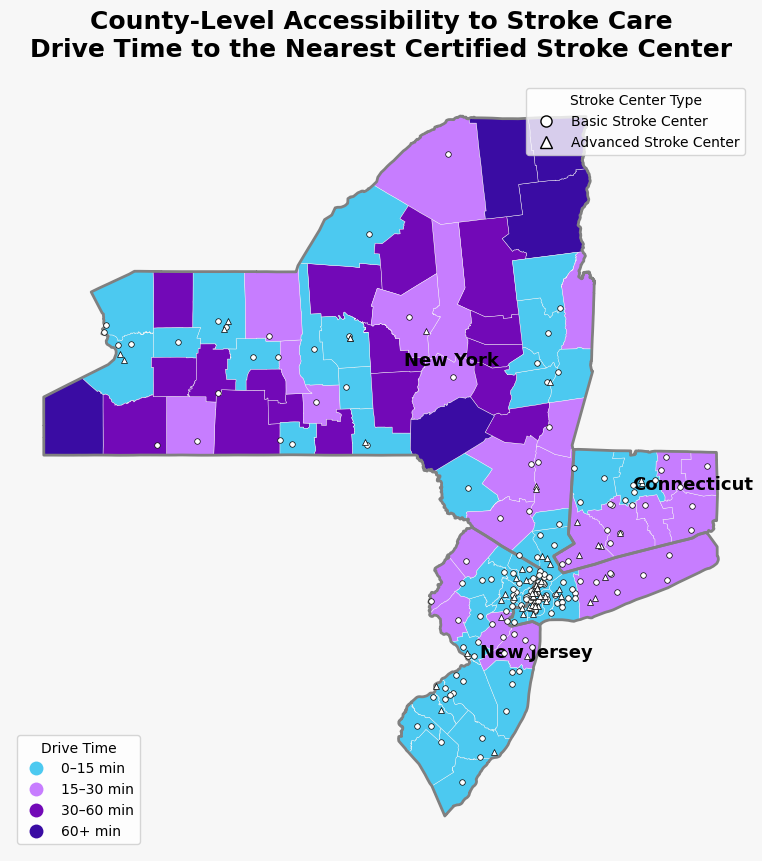

In [72]:
fig, ax = plt.subplots(
    figsize=(14,10),
    facecolor="#F7F7F7"
)

counties.plot(
    column="access_all",
    cmap=custom_cmap,
    edgecolor="#F5F5F5",
    linewidth=0.3,
    legend=True,
    categorical=True,
    legend_kwds={
        "title": "Drive Time",
        "loc": "lower left",
        "frameon": True
    },
    ax=ax
)

drive_time_legend = ax.get_legend()

states.boundary.plot(
    ax=ax,
    color="grey",
    linewidth=2
)

# Basic Stroke Centers
basic_gdf.plot(
    ax=ax,
    marker="o",
    color="white",
    edgecolor="black",
    markersize=16,
    linewidth=0.5,
    label="Basic Stroke Center",
    zorder=5
)

# Advanced Stroke Centers
advanced_gdf.plot(
    ax=ax,
    marker="^",
    color="white",
    edgecolor="black",
    markersize=18,
    linewidth=0.5,
    label="Advanced Stroke Center",
    zorder=6
)

stroke_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=8,
        label='Basic Stroke Center'
    ),
    Line2D(
        [0], [0],
        marker='^',
        linestyle='',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=9,
        label='Advanced Stroke Center'
    )
]

stroke_legend = ax.legend(
    handles=stroke_handles,
    title="Stroke Center Type",
    loc="upper right",
    frameon=True
)

ax.add_artist(drive_time_legend)
      

ax.text(
    -75.5, 42.8,
    "New York",
    fontsize=13,
    weight="bold",
    color="black"
)

ax.text(
    -74.6, 40.2,
    "New Jersey",
    fontsize=13,
    weight="bold",
    color="black"
)

ax.text(
    -72.8, 41.7,
    "Connecticut",
    fontsize=13,
    weight="bold",
    color="black"
)

plt.title(
    "County-Level Accessibility to Stroke Care\nDrive Time to the Nearest Certified Stroke Center",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.axis("off")

plt.show()

**Figure 6.** County-level accessibility to the nearest certified stroke center across New York, New Jersey, and Connecticut. Counties are classified by estimated drive time to the nearest certified stroke center (Basic or Advanced). White circles denote Basic Stroke Centers, while white triangles denote Advanced Stroke Centers.